# Full Factorial: Illustration of the scaling law of recurrent networks.

The aim of this notebook is to illustrate the effect on training process of hyperparameters changes.

## The Hyperparameters

The hyperparameters that we will consider are:

- Updates: the number of optimizer updates the model will take. One epoch performs
  `ceil(Split ratio * Number of sequences / Batch size)` updates - the split and the
  short final batch both matter - so *Epochs = ceil(Updates / updates per epoch)*.
- Sequence length: axes 1 of the input data, the length of the input sequences. (characters length, must be even: a term is 2 characters)
- Number of sequences: axes 0 of the input data, i.e. the number of sequences in the dataset. Half are generated from the grammar, half uniformly from the alphabet, and every label is obtained by parsing.


### Static Hyperparameters

The following hyperparameters will remain constant throughout the notebook:
- Batch size
- Learning rate (cosine schedule, restarted at each checkpoint - see below)
- Token dimension
- Split ratio (train/test)
- Seed (each cell is reseeded, so the dataset is a controlled variable rather than noise)

## Experiment

The analysis is performed through the full factorial technique over the three
factors *updates*, *number of sequences* and *sequence length*.

The grid is only swept over **number of sequences x sequence length** (9 runs). The
*updates* factor is not swept: each run is trained to the largest budget and a
checkpoint is harvested at every smaller budget along the way, giving the full
3 x 3 x 3 = 27 design points for the cost of the largest budget alone.

That substitution is only sound if a harvested checkpoint is interchangeable with a
run of that budget. A single cosine spanning the whole run would break it - the
512-update checkpoint would still be near `MAX_LR` while the 2048-update one had
annealed to `MIN_LR`, so the updates factor would be confounded with the learning
rate. The schedule therefore **restarts the cosine at each checkpoint**, annealing
`MAX_LR -> MIN_LR` within every segment, so each checkpoint is a fully annealed
model of its own budget.

### Checkpoint recovery

Artifacts are named by a deterministic experiment id, so an interrupted notebook can
be re-run: completed cells are skipped, and a partially finished cell resumes from
its last checkpoint instead of retraining. A checkpoint only counts as complete when
all three of its artifacts (backup, training metrics, validation metrics) are present.

## The Training Problem

Given a language grammar, the LSTM will be able to classify sequences of characters as valid or invalid according to the grammar rules.

BNF Definition:

$$
\begin{array}{rcl}
\langle\mathit{string}\rangle   & \mathrel{::=} & \langle\mathit{term}\rangle \\
                              & \mid          & \langle\mathit{string}\rangle \mathbin{\texttt{+}} \langle\mathit{term}\rangle \\[2pt]
\langle\mathit{term}\rangle   & \mathrel{::=} & AB, ED, OK \\[2pt]
\end{array}
$$

In [9]:
"""Static Hyperparameters Configuration"""

from examples.recurrent.scaling_law.helpers import Experiment

MAX_LR, MIN_LR = 1e-2, 1e-4

## Each experiment reseeds from Experiment.seed, so re-running - or resuming - a cell
## rebuilds exactly the same dataset. Without it the difference between two factor
## levels is confounded with the difference between two random data draws.
experiment = Experiment(batch_size=16, split_ratio=0.9, seed=777)

In [10]:
"""Model Architecture"""

from thorcino.activations import Sigmoid
from thorcino.layers.linear import Linear
from thorcino.layers.lstm import LSTM
from thorcino.layers.sequential import Sequential
from thorcino.losses import BinaryCrossEntropyLoss
from thorcino.optimizer import SGD
from thorcino.training.schedulers import CosineRestartSchedule
from thorcino.training.trainer import Trainer

def make_trainer(checkpoint_epochs: list[int]) -> Trainer:
    """Build a trainer whose schedule restarts at every checkpoint.

    The updates factor is read off checkpoints of a single run rather than from one
    run per budget. That only measures what it claims to if the learning rate at a
    checkpoint does not depend on how long the run continues afterwards: with one
    cosine spanning the whole run, the 512-update checkpoint would still sit near
    MAX_LR while the 2048-update one had annealed to MIN_LR, and the comparison
    would confound the update budget with the learning rate.

    Restarting the cosine at each checkpoint anneals MAX_LR -> MIN_LR within every
    segment, so each harvested checkpoint is a fully annealed model of its budget.
    """
    model = Sequential(
        LSTM(in_feature=3, hidden_units=3, out_type='n_to_1'),
        Linear(in_feature=3, out_feature=1),
        Sigmoid(),
    )
    loss = BinaryCrossEntropyLoss()
    optimizer = SGD(model.parameters, MAX_LR)
    scheduler = CosineRestartSchedule(MAX_LR, MIN_LR, [e + 1 for e in checkpoint_epochs])

    return Trainer(model, loss, optimizer, scheduler)

## Validation Set

A validation set is used to evaluate the model performance in order to choose the best hyperparameters configuration.
The validation set is shared across all runs.

Considering that the problem is length independent, several sub validation set are build, each set has a different sequence length, this last, increase by a factor of 2, starting from the minimum sequence length used in the experiments.

In [11]:
"""Create the Validation Set"""

VAL_SEQUENCE_LENGTHS = [8, 16, 32, 64, 96]

val_dataset = experiment.validation_set(500, VAL_SEQUENCE_LENGTHS)

validation set: SEQUENCE_LENGTH=8 X=(500, 8, 3) Y=(500, 1) positives=0.500
validation set: SEQUENCE_LENGTH=16 X=(500, 16, 3) Y=(500, 1) positives=0.500
validation set: SEQUENCE_LENGTH=32 X=(500, 32, 3) Y=(500, 1) positives=0.500
validation set: SEQUENCE_LENGTH=64 X=(500, 64, 3) Y=(500, 1) positives=0.500
validation set: SEQUENCE_LENGTH=96 X=(500, 96, 3) Y=(500, 1) positives=0.500


## The Training Process

`Experiment.run_full_factorial` trains one run per grid cell, up to the largest update
budget. At every budget in `hyperparams['updates']` three artifacts are written: the
full checkpoint (model, optimizer and scheduler state), the training metrics, and the
scores against the shared validation set.

The validation sweep is evaluated with `record=False` so it does not append to the same
history the training curve is read from; the periodic test evaluation every `eval_step`
epochs is the only thing that does.

In [12]:
"""Running the Full Factorial"""

hyperparams = {
    'updates': [2048, 5096, 10192],
    'number_of_sequence': [256, 512, 1024],
    'sequence_length': [16, 32, 64]
}

completed_checkpoints = experiment.run_full_factorial(hyperparams, make_trainer, val_dataset)

recovered 0 completed checkpoint(s): []
-----------------NEW EXPERIMENT STARTED-----------------
experiment hyperparameters: EPOCHS=680 UPDATES=10192, NUMBER_OF_SEQUENCE=256, SEQUENCE_LENGTH=16
updates per epoch: 15, checkpoint epochs: [136, 339, 679]
saved checkpoint: EPOCHS=137, UPDATES=2055, NUMBER_OF_SEQUENCE=256, SEQUENCE_LENGTH=16
saved checkpoint: EPOCHS=340, UPDATES=5100, NUMBER_OF_SEQUENCE=256, SEQUENCE_LENGTH=16
saved checkpoint: EPOCHS=680, UPDATES=10200, NUMBER_OF_SEQUENCE=256, SEQUENCE_LENGTH=16
total experiment age: 140 seconds
-------------------EXPERIMENT ENDED------------------


-----------------NEW EXPERIMENT STARTED-----------------
experiment hyperparameters: EPOCHS=680 UPDATES=10192, NUMBER_OF_SEQUENCE=256, SEQUENCE_LENGTH=32
updates per epoch: 15, checkpoint epochs: [136, 339, 679]
saved checkpoint: EPOCHS=137, UPDATES=2055, NUMBER_OF_SEQUENCE=256, SEQUENCE_LENGTH=32
saved checkpoint: EPOCHS=340, UPDATES=5100, NUMBER_OF_SEQUENCE=256, SEQUENCE_LENGTH=32
saved chec

In [13]:
from examples.recurrent.scaling_law.helpers import FullFactorialMetrics

validation_metrics = FullFactorialMetrics(experiment.validation_folder)

## The Training Metrics

Considering the factors increase exponentially, the metrics will be plotted in log-log scale, oherwise the scaling law would be hidden by the exponential growth of the factors.

Only the validation metrics will be considered.

For each run, we will plot the results of the final epoch, in order to eliminate the upward bias, if we were to plot the best epoch.

One 3D graph will be plotted for whole metrics.

In [14]:
"""Take only the last results of every validation metrics."""

grouped_metrics = []
for seq_len in hyperparams['sequence_length']:
    grouped_metrics.append(
    {
        'sequence_length': seq_len,
        'metrics': [x for x in validation_metrics.metrics if x.metadata.sequence_length == seq_len]
    })

grouped_metrics

[{'sequence_length': 16,
  'metrics': [ExperimentArtifact(data=Artifact(data={'sequence_lengths': [8, 16, 32, 64, 96], 'loss_history': [0.6893216148018837, 0.6900390703231096, 0.6946720276027918, 0.6910122018307447, 0.6917077302932739], 'accuracy_history': [np.float64(0.502), np.float64(0.494), np.float64(0.438), np.float64(0.502), np.float64(0.472)]}), metadata=ExperimentInfo(experiment_id=0, epochs=137, updates=2055, n_sequence=256, sequence_length=16, age=26)),
   ExperimentArtifact(data=Artifact(data={'sequence_lengths': [8, 16, 32, 64, 96], 'loss_history': [0.6626780163496733, 0.6624379307031631, 0.6665700729936361, 0.6621872428804636, 0.6643354892730713], 'accuracy_history': [np.float64(0.668), np.float64(0.676), np.float64(0.692), np.float64(0.716), np.float64(0.672)]}), metadata=ExperimentInfo(experiment_id=1, epochs=340, updates=5100, n_sequence=256, sequence_length=16, age=68)),
   ExperimentArtifact(data=Artifact(data={'sequence_lengths': [8, 16, 32, 64, 96], 'loss_history':

### Reading the three factors off two axes

Three factors and one response are four dimensions, and a surface carries only three.
The sequence length is therefore spent on the panels rather than on an axis: each panel
is a real `updates x number of sequences` slice at one length, not a projection that
averages a factor away.

Both factor axes are log2 and centred on the middle level, since the levels grow
geometrically. Each artifact also holds one score per validation length, and that axis
is collapsed first - `eval_index=None` averages over the validation lengths, an integer
picks one of `VAL_SEQUENCE_LENGTHS`.


In [16]:
"""Validation metrics as surfaces, one panel per sequence length."""

import matplotlib.pyplot as plt

from examples.recurrent.scaling_law.helpers import plot_metric_surfaces
print(grouped_metrics)
fig = plot_metric_surfaces(grouped_metrics, hyperparams, 'loss_history')
plt.show()

fig = plot_metric_surfaces(grouped_metrics, hyperparams, 'accuracy_history')
plt.show()


[{'sequence_length': 16, 'metrics': [ExperimentArtifact(data=Artifact(data={'sequence_lengths': [8, 16, 32, 64, 96], 'loss_history': [0.6893216148018837, 0.6900390703231096, 0.6946720276027918, 0.6910122018307447, 0.6917077302932739], 'accuracy_history': [np.float64(0.502), np.float64(0.494), np.float64(0.438), np.float64(0.502), np.float64(0.472)]}), metadata=ExperimentInfo(experiment_id=0, epochs=137, updates=2055, n_sequence=256, sequence_length=16, age=26)), ExperimentArtifact(data=Artifact(data={'sequence_lengths': [8, 16, 32, 64, 96], 'loss_history': [0.6626780163496733, 0.6624379307031631, 0.6665700729936361, 0.6621872428804636, 0.6643354892730713], 'accuracy_history': [np.float64(0.668), np.float64(0.676), np.float64(0.692), np.float64(0.716), np.float64(0.672)]}), metadata=ExperimentInfo(experiment_id=1, epochs=340, updates=5100, n_sequence=256, sequence_length=16, age=68)), ExperimentArtifact(data=Artifact(data={'sequence_lengths': [8, 16, 32, 64, 96], 'loss_history': [0.4713

ValueError: list.index(x): x not in list

### The same data, flat

The grid is 3x3, so each surface is four quads drawn between nine measurements and most
of what it shows is interpolation. The exponent of the scaling law is a slope, and a
slope is read off a log-log line far more reliably than off a tilted surface, so the
surfaces are kept for the shape of the response and these panels for its rate.


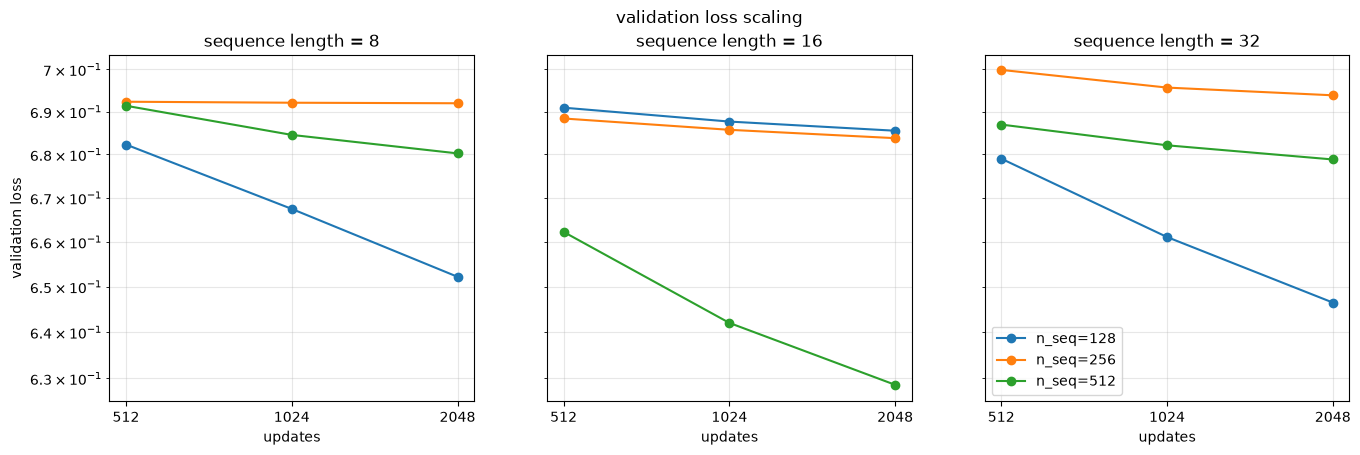

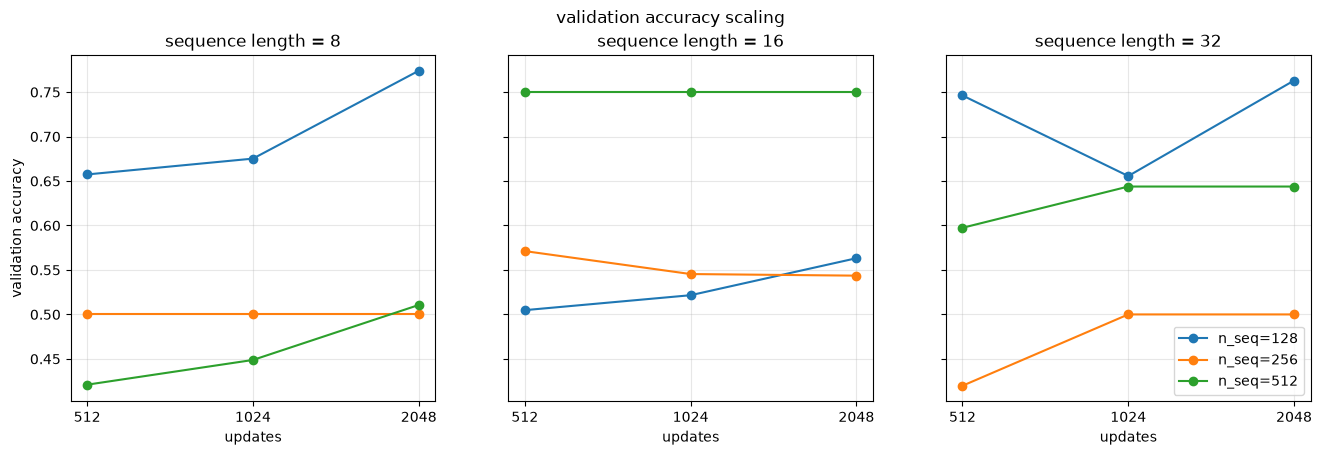

In [ ]:
"""Validation metrics as log-log scaling curves."""

from examples.recurrent.scaling_law.helpers import plot_metric_scaling

fig = plot_metric_scaling(grouped_metrics, hyperparams, 'loss_history')
plt.show()

fig = plot_metric_scaling(grouped_metrics, hyperparams, 'accuracy_history')
plt.show()
